#Deep Learning Based DDoS Attack Detection

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

Load Dataset and Preprocessing

In [ ]:
    df = pd.read_csv("/content/Portmap.csv")
    print("Data shape:", df.shape)
    print("Class distribution:\n", df['Label'].value_counts())
    # Drop non-numeric or irrelevant columns
    drop_cols = ['SourceIP', 'DestinationIP', 'Protocol', 'Timestamp', 'Unnamed: 0', 'Unnamed0']
    df.drop([col for col in drop_cols if col in df.columns], axis=1, inplace=True)

    # Normalize labels to binary
    normal_terms = ['normal', 'benign']
    df['Label'] = df['Label'].astype(str).str.lower().str.strip()
    df['Label'] = df['Label'].apply(lambda x: 0 if x in normal_terms else 1)

    # Clean data
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    # Clip extremes and convert remaining object columns
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].clip(-1e10, 1e10)
        elif df[col].dtype == 'object':
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                df.drop(col, axis=1, inplace=True)


/tmp/ipython-input-3845747869.py:1: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Portmap.csv")


Data shape: (71431, 88)
Class distribution:
 Label
Portmap    66707
BENIGN      4723
Name: count, dtype: int64


Splitting Dataset (Training and Testing)

In [ ]:
X = df.drop('Label', axis=1).values
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.nan_to_num(X_train, nan=0, posinf=1e10, neginf=-1e10)
X_test = np.nan_to_num(X_test, nan=0, posinf=1e10, neginf=-1e10)

# Reshape for LSTM input: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (57144, 1, 81)
Test shape: (14287, 1, 81)


Build Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 64)          │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,825 (194.63 KB)

 Trainable params: 49,825 (194.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9917 - loss: 0.1166 - val_accuracy: 0.9969 - val_loss: 0.0088
Epoch 2/5
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9975 - loss: 0.0072 - val_accuracy: 0.9980 - val_loss: 0.0063
Epoch 3/5
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9981 - val_loss: 0.0052
Epoch 4/5
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9988 - loss: 0.0035 - val_accuracy: 0.9985 - val_loss: 0.0038
Epoch 5/5
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9987 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0032


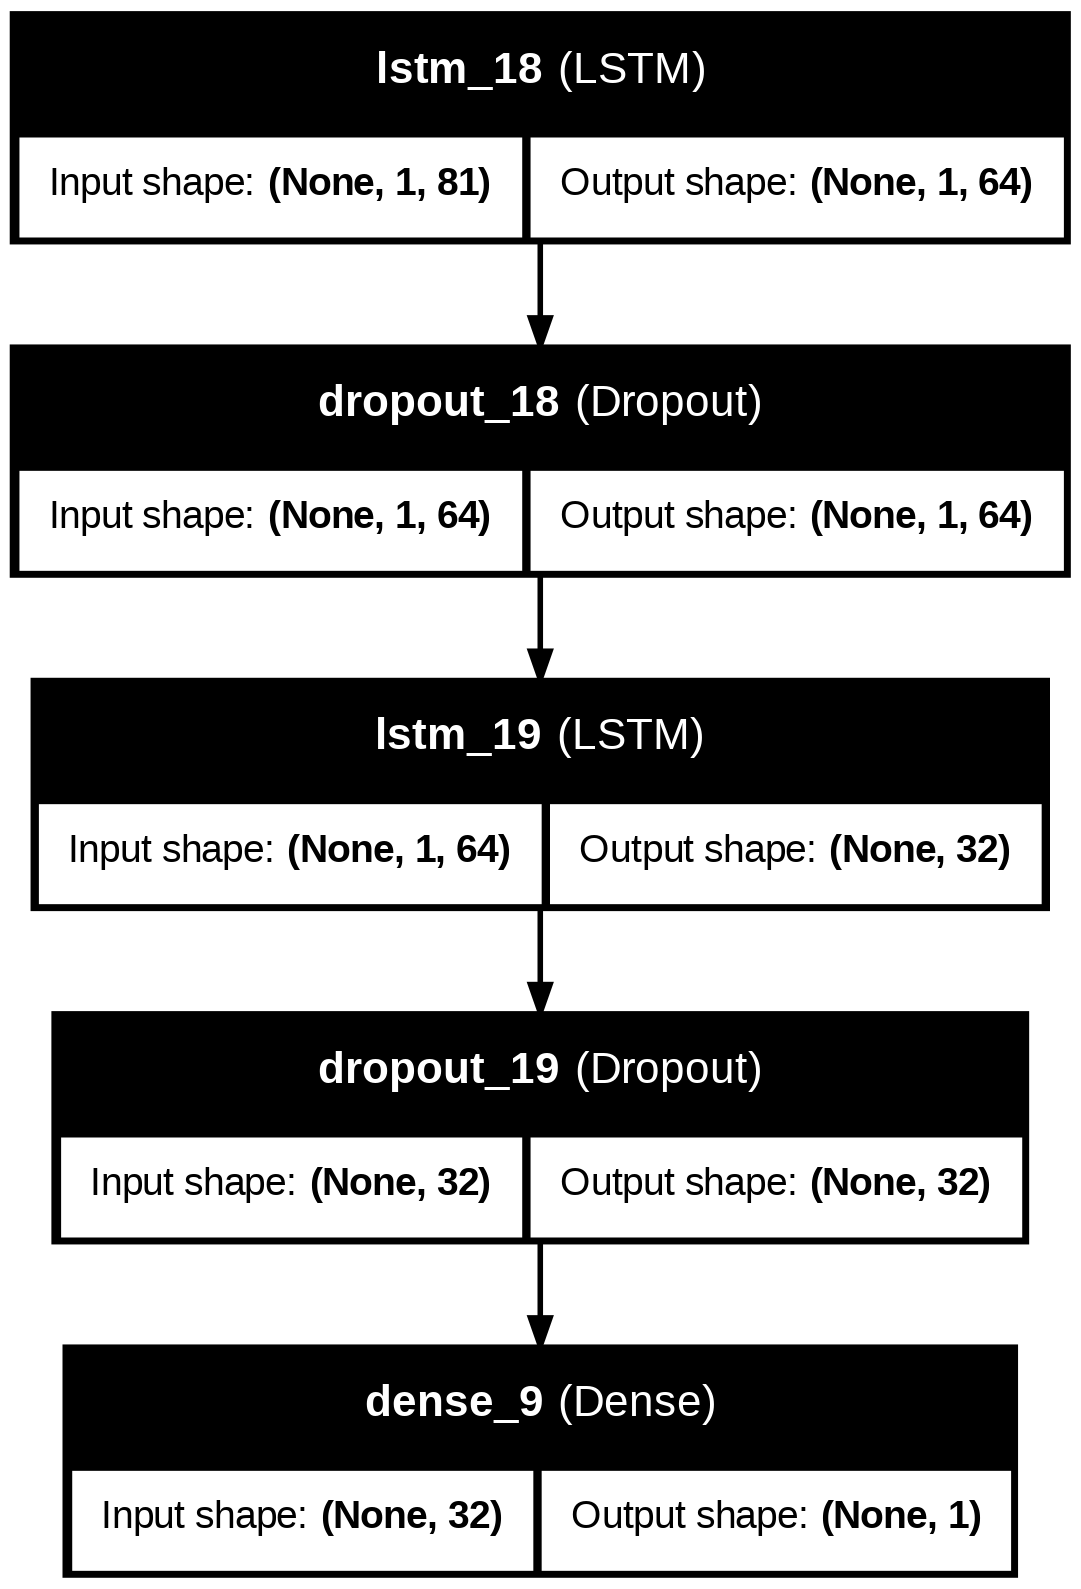

In [ ]:
def lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(32))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

model = lstm_model((X_train.shape[1], X_train.shape[2]))
model.summary()
history = model.fit(X_train, y_train, validation_split=0.2, epochs=5)

# Plot model architecture
plot_model(model, show_shapes=True, show_layer_names=True)

Plot Training History

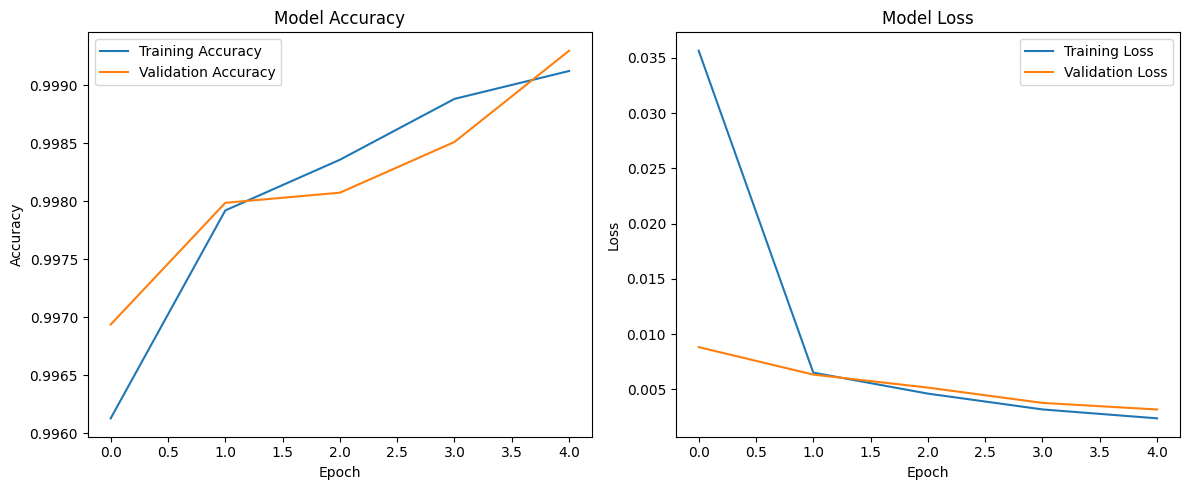

In [ ]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Training and Testing Accuracy

In [ ]:
train_pred = (model.predict(X_train) > 0.5).astype(int)
train_accuracy = accuracy_score(y_train, train_pred)

test_pred = (model.predict(X_test) > 0.5).astype(int)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nTrain Accuracy: ", train_accuracy)

print("\nTest Accuracy: ", test_accuracy)

746/746 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Train Accuracy:  0.9978217158176944

Test Accuracy:  0.9979896130005026


Model Evaluation

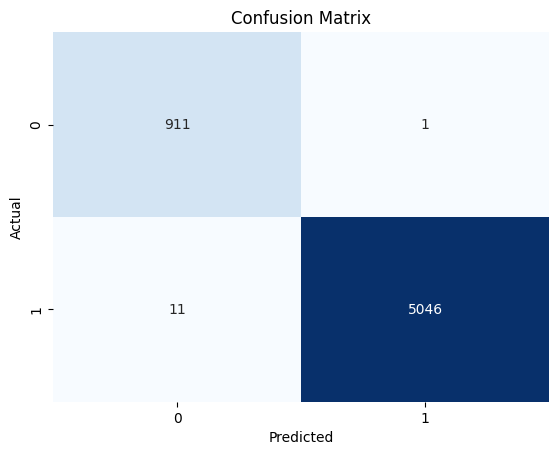

In [ ]:
    cm = confusion_matrix(y_test, test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Making Prediction on New Data

In [ ]:
# This matches the feature order from your training data
new_traffic = pd.DataFrame([[
    # Flow features
     0, 0, 94389822, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.158915439, 6742130.143, 12223762.43, 33740974, 1, 94389822, 6742130.143, 12223762.43, 33740974, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.158915439, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0, -1, -1, 0, 0, 440916, 881827.3333, 1763657, 2, 23156323, 11984456.59, 33740974, 6125514, 0, 0
]])

# Verify feature count matches
if new_traffic.shape[1] != X_train.shape[2]:
    missing = X_train.shape[2] - new_traffic.shape[1]
    print(f"Error: Missing {missing} features. Need exactly {X_train.shape[2]} features.")
else:
    # Preprocess
    new_traffic = scaler.transform(new_traffic)
    new_traffic = new_traffic.reshape(1, 1, new_traffic.shape[1])

    # Predict
    prediction = model.predict(new_traffic)
    result = "DDoS" if prediction > 0.5 else "Normal"
    print(f"Prediction: {result} (Confidence: {prediction[0][0]:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction: DDoS (Confidence: 0.9999)
